In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import regex as re

# Parsing traces into dataframes

In [176]:
flt = r'\d*\.*\d*e?\+?-?\d*'
error_type = lambda e,t: lambda x: e if x is None else t(x)
i32 = error_type(None, np.int32)
f64 = error_type(None, np.float64)
f64_TO = error_type('T.O.', np.float64)
    
def experiment_to_df(fname, dir='.', ext='.dat', patterns=None, labels_list=None, types_list=None):
    if patterns is None:
        pattern1 = r'(\S*) w:(\S*)\s.*'
        pattern2 = r'T.O.|Done\(\d*\):($flt)\s+#nodes:($flt)\/($flt)\s+P\/D:($flt)\/($flt)\s+Time:($flt)\/($flt)s\s+LIM\?:($flt)\s+Seen:($flt)'.replace(r'$flt', flt)
        patterns = [pattern1, pattern2]
    if labels_list is None:
        labels1 = ['Bench', 'Width']
        labels2 = ['Opt', 'nodes1', 'nodes2', 'P', 'D', 'Opt Time', 'Proof Time', None, None]
        labels_list = [labels1, labels2]
    if types_list is None:
        type1 = [str, np.int32]
        type2 = [f64, i32, i32, i32, i32, f64_TO, f64_TO, None, None]
        types_list = [type1, type2]

    if len(patterns) != len(labels_list) or len(labels_list) != len(types_list):
        raise ValueError('patterns, labels_list, and types_list must be the same length')

    csv = {}
    with open(f'{dir}/{fname}{ext}') as f:  
        i = 0
        p = False
        csv["Original Lines"] = []
        original_lines = []
        for line in f.readlines():
            pattern = patterns[i]
            labels = labels_list[i]
            types = types_list[i]

            i += 1
            original_lines.append(line)
            if i == len(patterns):
                i = 0
                csv["Original Lines"].append("\n".join(original_lines))
                original_lines = []

            match = re.search(pattern, line)
            if match is None: continue
            groups = match.groups()

            if len(groups) == 0:
                groups = [None] * len(labels)
            
            for label, match, convert in zip(labels, groups, types):
                if label is None or convert is None: continue
                match = convert(match)
                
                if label in csv: csv[label].append(match)
                else: csv[label] = [match]
            

    return pd.DataFrame.from_dict(csv, orient='index').transpose()

In [177]:
def didp_to_df(fname,dir='.',ext='.dat'):
    patterns = [
        r'(\S*) w:(\S*)\s.*',
        r'T.O.|(\S*) (\S*) (\S*) (\S*)'
    ]
    labels_list = [
        ['Bench','Width'],
        ['Opt','nodes1','nodes2','Proof Time']
    ]
    types_list = [
        [str,str],
        [i32,i32,i32,f64_TO]
    ]
    return experiment_to_df(fname, dir, ext, patterns, labels_list, types_list)    

#Done(64):140000.0000000000000000         #nodes:1/1      P/D:0/0         Time:0.0030000000000000/0.0030000000000000s         LIM?:0  Seen:0
#64 140000.0000000000000000 1 1 0 0 0.0030000000000000 0.0030000000000000 0 0
def codd_to_df(fname,dir='.',ext='.dat'):
    patterns = [
        r'(\S*) (\S*) w:(\S*)\s.*',
        r'T.O.|(\S*) (\S*) (\S*) (\S*) (\S*) (\S*) (\S*) (\S*) (\S*) (\S*)'
    ]
    labels_list = [
        ['Solver', 'Bench','Width'],
        ['Width','Opt','nodes1','nodes2','pruned','domd','Opt Time','Proof Time','lim', 'seen']
    ]
    types_list = [
        [str,str,i32],
        [i32,f64,i32,i32,i32,i32,f64_TO,f64_TO,i32,i32]
    ]
    return experiment_to_df(fname, dir, ext, patterns, labels_list, types_list)    

#Done(1):140000.000000    #iterations:3   Time:0.001000/0.001000s        Width: 1/4
#1 140000.000000 3 0.001000 0.001000 1 4
def coddnq_to_df(fname,dir='.',ext='.dat'):
    patterns = [
        r'(\S*) (\S*) w:(\S*)\s.*',
        r'T.O.|\S* (\S*) (\S*) (\S*) (\S*) \S* (\S*)'
    ]
    labels_list = [
        ['Solver', 'Bench','Initial Width'],
        ['Opt','iterations','Opt Time','Proof Time','Width']
    ]
    types_list = [
        [str,str,i32],
        [f64,i32,f64_TO,f64_TO,i32]
    ]
    return experiment_to_df(fname, dir, ext, patterns, labels_list, types_list)    

In [178]:
def experiment_to_df_codd(fname):
    exp = codd_to_df(fname)  
    return exp

def experiment_to_df_coddnq(fname):
    exp = coddnq_to_df(fname)  
    return exp

import re
premultiplied_instances = '|'.join([re.escape(i) for i in ['Langevin/N20ft301.dat', 'Langevin/N20ft301.dat', 'Langevin/N20ft302.dat', 'Langevin/N20ft302.dat', 'Langevin/N20ft303.dat', 'Langevin/N20ft303.dat', 'Langevin/N20ft304.dat', 'Langevin/N20ft304.dat', 'Langevin/N20ft305.dat', 'Langevin/N20ft305.dat', 'Langevin/N20ft306.dat', 'Langevin/N20ft306.dat', 'Langevin/N20ft307.dat', 'Langevin/N20ft307.dat', 'Langevin/N20ft308.dat', 'Langevin/N20ft308.dat', 'Langevin/N20ft309.dat', 'Langevin/N20ft309.dat', 'Langevin/N20ft310.dat', 'Langevin/N20ft310.dat', 'Langevin/N20ft401.dat', 'Langevin/N20ft401.dat', 'Langevin/N20ft402.dat', 'Langevin/N20ft402.dat', 'Langevin/N20ft403.dat', 'Langevin/N20ft403.dat', 'Langevin/N20ft404.dat', 'Langevin/N20ft404.dat', 'Langevin/N20ft405.dat', 'Langevin/N20ft405.dat', 'Langevin/N20ft406.dat', 'Langevin/N20ft406.dat', 'Langevin/N20ft407.dat', 'Langevin/N20ft407.dat', 'Langevin/N20ft408.dat', 'Langevin/N20ft408.dat', 'Langevin/N20ft409.dat', 'Langevin/N20ft409.dat', 'Langevin/N20ft410.dat', 'Langevin/N20ft410.dat', 'Langevin/N40ft201.dat', 'Langevin/N40ft201.dat', 'Langevin/N40ft202.dat', 'Langevin/N40ft202.dat', 'Langevin/N40ft203.dat', 'Langevin/N40ft203.dat', 'Langevin/N40ft204.dat', 'Langevin/N40ft204.dat', 'Langevin/N40ft205.dat', 'Langevin/N40ft205.dat', 'Langevin/N40ft206.dat', 'Langevin/N40ft206.dat', 'Langevin/N40ft207.dat', 'Langevin/N40ft207.dat', 'Langevin/N40ft208.dat', 'Langevin/N40ft208.dat', 'Langevin/N40ft209.dat', 'Langevin/N40ft209.dat', 'Langevin/N40ft210.dat', 'Langevin/N40ft210.dat', 'Langevin/N40ft401.dat', 'Langevin/N40ft401.dat', 'Langevin/N40ft402.dat', 'Langevin/N40ft402.dat', 'Langevin/N40ft403.dat', 'Langevin/N40ft403.dat', 'Langevin/N40ft404.dat', 'Langevin/N40ft404.dat', 'Langevin/N40ft405.dat', 'Langevin/N40ft405.dat', 'Langevin/N40ft406.dat', 'Langevin/N40ft406.dat', 'Langevin/N40ft407.dat', 'Langevin/N40ft407.dat', 'Langevin/N40ft408.dat', 'Langevin/N40ft408.dat', 'Langevin/N40ft409.dat', 'Langevin/N40ft409.dat', 'Langevin/N40ft410.dat', 'Langevin/N40ft410.dat', 'Langevin/N60ft201.dat', 'Langevin/N60ft201.dat', 'Langevin/N60ft202.dat', 'Langevin/N60ft202.dat', 'Langevin/N60ft203.dat', 'Langevin/N60ft203.dat', 'Langevin/N60ft204.dat', 'Langevin/N60ft204.dat', 'Langevin/N60ft205.dat', 'Langevin/N60ft205.dat', 'Langevin/N60ft206.dat', 'Langevin/N60ft206.dat', 'Langevin/N60ft207.dat', 'Langevin/N60ft207.dat', 'Langevin/N60ft208.dat', 'Langevin/N60ft208.dat', 'Langevin/N60ft209.dat', 'Langevin/N60ft209.dat', 'Langevin/N60ft210.dat', 'Langevin/N60ft210.dat', 'Langevin/N60ft301.dat', 'Langevin/N60ft301.dat', 'Langevin/N60ft302.dat', 'Langevin/N60ft302.dat', 'Langevin/N60ft303.dat', 'Langevin/N60ft303.dat', 'Langevin/N60ft304.dat', 'Langevin/N60ft304.dat', 'Langevin/N60ft305.dat', 'Langevin/N60ft305.dat', 'Langevin/N60ft306.dat', 'Langevin/N60ft306.dat', 'Langevin/N60ft307.dat', 'Langevin/N60ft307.dat', 'Langevin/N60ft308.dat', 'Langevin/N60ft308.dat', 'Langevin/N60ft309.dat', 'Langevin/N60ft309.dat', 'Langevin/N60ft310.dat', 'Langevin/N60ft310.dat', 'Langevin/N60ft401.dat', 'Langevin/N60ft401.dat', 'Langevin/N60ft402.dat', 'Langevin/N60ft402.dat', 'Langevin/N60ft403.dat', 'Langevin/N60ft403.dat', 'Langevin/N60ft404.dat', 'Langevin/N60ft404.dat', 'Langevin/N60ft405.dat', 'Langevin/N60ft405.dat', 'Langevin/N60ft406.dat', 'Langevin/N60ft406.dat', 'Langevin/N60ft407.dat', 'Langevin/N60ft407.dat', 'Langevin/N60ft408.dat', 'Langevin/N60ft408.dat', 'Langevin/N60ft409.dat', 'Langevin/N60ft409.dat', 'Langevin/N60ft410.dat', 'Langevin/N60ft410.dat', 'SolomonPesant/rc201.0', 'SolomonPesant/rc201.0', 'SolomonPesant/rc201.1', 'SolomonPesant/rc201.1', 'SolomonPesant/rc201.2', 'SolomonPesant/rc201.2', 'SolomonPesant/rc201.3', 'SolomonPesant/rc201.3', 'SolomonPesant/rc202.0', 'SolomonPesant/rc202.0', 'SolomonPesant/rc202.1', 'SolomonPesant/rc202.1', 'SolomonPesant/rc202.2', 'SolomonPesant/rc202.2', 'SolomonPesant/rc202.3', 'SolomonPesant/rc202.3', 'SolomonPesant/rc203.0', 'SolomonPesant/rc203.0', 'SolomonPesant/rc203.1', 'SolomonPesant/rc203.1', 'SolomonPesant/rc203.2', 'SolomonPesant/rc203.2', 'SolomonPesant/rc204.0', 'SolomonPesant/rc204.0', 'SolomonPesant/rc204.1', 'SolomonPesant/rc204.1', 'SolomonPesant/rc204.2', 'SolomonPesant/rc204.2', 'SolomonPesant/rc205.0', 'SolomonPesant/rc205.0', 'SolomonPesant/rc205.1', 'SolomonPesant/rc205.1', 'SolomonPesant/rc205.2', 'SolomonPesant/rc205.2', 'SolomonPesant/rc205.3', 'SolomonPesant/rc205.3', 'SolomonPesant/rc206.0', 'SolomonPesant/rc206.0', 'SolomonPesant/rc206.1', 'SolomonPesant/rc206.1', 'SolomonPesant/rc206.2', 'SolomonPesant/rc206.2', 'SolomonPesant/rc207.0', 'SolomonPesant/rc207.0', 'SolomonPesant/rc207.1', 'SolomonPesant/rc207.1', 'SolomonPesant/rc207.2', 'SolomonPesant/rc207.2', 'SolomonPesant/rc208.0', 'SolomonPesant/rc208.0', 'SolomonPesant/rc208.1', 'SolomonPesant/rc208.1', 'SolomonPesant/rc208.2', 'SolomonPesant/rc208.2', 'SolomonPotvinBengio/rc_201.1.txt', 'SolomonPotvinBengio/rc_201.1.txt', 'SolomonPotvinBengio/rc_201.2.txt', 'SolomonPotvinBengio/rc_201.2.txt', 'SolomonPotvinBengio/rc_201.3.txt', 'SolomonPotvinBengio/rc_201.3.txt', 'SolomonPotvinBengio/rc_201.4.txt', 'SolomonPotvinBengio/rc_201.4.txt', 'SolomonPotvinBengio/rc_202.1.txt', 'SolomonPotvinBengio/rc_202.1.txt', 'SolomonPotvinBengio/rc_202.2.txt', 'SolomonPotvinBengio/rc_202.2.txt', 'SolomonPotvinBengio/rc_202.3.txt', 'SolomonPotvinBengio/rc_202.3.txt', 'SolomonPotvinBengio/rc_202.4.txt', 'SolomonPotvinBengio/rc_202.4.txt', 'SolomonPotvinBengio/rc_203.1.txt', 'SolomonPotvinBengio/rc_203.1.txt', 'SolomonPotvinBengio/rc_203.2.txt', 'SolomonPotvinBengio/rc_203.2.txt', 'SolomonPotvinBengio/rc_203.3.txt', 'SolomonPotvinBengio/rc_203.3.txt', 'SolomonPotvinBengio/rc_203.4.txt', 'SolomonPotvinBengio/rc_203.4.txt', 'SolomonPotvinBengio/rc_204.1.txt', 'SolomonPotvinBengio/rc_204.1.txt', 'SolomonPotvinBengio/rc_204.2.txt', 'SolomonPotvinBengio/rc_204.2.txt', 'SolomonPotvinBengio/rc_204.3.txt', 'SolomonPotvinBengio/rc_204.3.txt', 'SolomonPotvinBengio/rc_205.1.txt', 'SolomonPotvinBengio/rc_205.1.txt', 'SolomonPotvinBengio/rc_205.2.txt', 'SolomonPotvinBengio/rc_205.2.txt', 'SolomonPotvinBengio/rc_205.3.txt', 'SolomonPotvinBengio/rc_205.3.txt', 'SolomonPotvinBengio/rc_205.4.txt', 'SolomonPotvinBengio/rc_205.4.txt', 'SolomonPotvinBengio/rc_206.1.txt', 'SolomonPotvinBengio/rc_206.1.txt', 'SolomonPotvinBengio/rc_206.2.txt', 'SolomonPotvinBengio/rc_206.2.txt', 'SolomonPotvinBengio/rc_206.3.txt', 'SolomonPotvinBengio/rc_206.3.txt', 'SolomonPotvinBengio/rc_206.4.txt', 'SolomonPotvinBengio/rc_206.4.txt', 'SolomonPotvinBengio/rc_207.1.txt', 'SolomonPotvinBengio/rc_207.1.txt', 'SolomonPotvinBengio/rc_207.2.txt', 'SolomonPotvinBengio/rc_207.2.txt', 'SolomonPotvinBengio/rc_207.3.txt', 'SolomonPotvinBengio/rc_207.3.txt', 'SolomonPotvinBengio/rc_207.4.txt', 'SolomonPotvinBengio/rc_207.4.txt', 'SolomonPotvinBengio/rc_208.1.txt', 'SolomonPotvinBengio/rc_208.1.txt', 'SolomonPotvinBengio/rc_208.2.txt', 'SolomonPotvinBengio/rc_208.2.txt', 'SolomonPotvinBengio/rc_208.3.txt', 'SolomonPotvinBengio/rc_208.3.txt']])
def experiment_to_df_didp(fname, opt_name='Opt', mult=10_000):
    exp = didp_to_df(fname)   
    mask = ~exp['Bench'].str.contains(premultiplied_instances)
    exp.loc[mask, opt_name] = exp.loc[mask, opt_name] * mult
    return exp

In [179]:
import os
print(os.getcwd())

/Users/ems/work/CODD/CODD/experiments


In [180]:
didp_bound = experiment_to_df_didp('didp_bound/didp')

didp_bound = didp_bound.dropna()
didp_bound["Bench"] = didp_bound["Bench"].str.removesuffix('_bound.yaml') \
                                         .str.removeprefix('../data/tsptw/')

didp_bound

,Original Lines,Bench,Width,Opt,nodes1,nodes2,Proof Time
0,../data/tsptw/AFG/rbg010a.tw_bound.yaml w:_ 27...,AFG/rbg010a.tw,_,6710000,345,425,0.000945
1,../data/tsptw/AFG/rbg016a.tw_bound.yaml w:_ 27...,AFG/rbg016a.tw,_,9380000,671,810,0.00257
2,../data/tsptw/AFG/rbg016b.tw_bound.yaml w:_ 27...,AFG/rbg016b.tw,_,13040000,7337,9894,0.02554
3,../data/tsptw/AFG/rbg017.2.tw_bound.yaml w:_ 2...,AFG/rbg017.2.tw,_,8520000,115216,167537,0.472031
4,../data/tsptw/AFG/rbg017a.tw_bound.yaml w:_ 27...,AFG/rbg017a.tw,_,42960000,1221,1517,0.003744
...,...,...,...,...,...,...,...
460,../data/tsptw/SolomonPotvinBengio/rc_207.1.txt...,SolomonPotvinBengio/rc_207.1.txt,_,7326830,11520610,15937905,105.699303
461,../data/tsptw/SolomonPotvinBengio/rc_207.2.txt...,SolomonPotvinBengio/rc_207.2.txt,_,7012511,13297888,16752586,124.057368
463,../data/tsptw/SolomonPotvinBengio/rc_207.4.txt...,SolomonPotvinBengio/rc_207.4.txt,_,1196388,161,217,0.000218
467,../data/tsptw/toy/toy1.tw_bound.yaml w:_ 27.08...,toy/toy1.tw,_,140000,8,12,0.000056


In [181]:
didp_nobound = experiment_to_df_didp('didp_nobound/didp')

didp_nobound = didp_nobound.dropna()
didp_nobound["Bench"] = didp_nobound["Bench"].str.removesuffix('_nobound.yaml') \
                                             .str.removeprefix('../data/tsptw/')

didp_nobound

,Original Lines,Bench,Width,Opt,nodes1,nodes2,Proof Time
0,../data/tsptw/AFG/rbg010a.tw_nobound.yaml w:_ ...,AFG/rbg010a.tw,_,6710000,347,436,0.000918
1,../data/tsptw/AFG/rbg016a.tw_nobound.yaml w:_ ...,AFG/rbg016a.tw,_,9380000,671,831,0.002464
2,../data/tsptw/AFG/rbg016b.tw_nobound.yaml w:_ ...,AFG/rbg016b.tw,_,13040000,7813,10390,0.024505
3,../data/tsptw/AFG/rbg017.2.tw_nobound.yaml w:_...,AFG/rbg017.2.tw,_,8520000,140148,213796,0.505462
4,../data/tsptw/AFG/rbg017a.tw_nobound.yaml w:_ ...,AFG/rbg017a.tw,_,42960000,1271,1607,0.003759
...,...,...,...,...,...,...,...
460,../data/tsptw/SolomonPotvinBengio/rc_207.1.txt...,SolomonPotvinBengio/rc_207.1.txt,_,7326830,11614631,16161185,103.046364
461,../data/tsptw/SolomonPotvinBengio/rc_207.2.txt...,SolomonPotvinBengio/rc_207.2.txt,_,7012511,13262107,16764068,117.690891
463,../data/tsptw/SolomonPotvinBengio/rc_207.4.txt...,SolomonPotvinBengio/rc_207.4.txt,_,1196388,320,472,0.000375
467,../data/tsptw/toy/toy1.tw_nobound.yaml w:_ 28....,toy/toy1.tw,_,140000,14,20,0.000074


In [182]:
codd_suffixes = []

In [183]:
coddnq = experiment_to_df_coddnq('coddnq/coddnq')

coddnq = coddnq.dropna()
coddnq["Bench"] = coddnq["Bench"].str.removeprefix('../data/tsptw/')

coddnq

,Original Lines,Solver,Bench,Initial Width,Opt,iterations,Opt Time,Proof Time,Width
0,tsptw_triangleRONQ ../data/tsptw/AFG/rbg010a.t...,tsptw_triangleRONQ,AFG/rbg010a.tw,1,6710000.0,7,0.001,0.001,64
1,tsptw_triangleRONQ ../data/tsptw/AFG/rbg016a.t...,tsptw_triangleRONQ,AFG/rbg016a.tw,1,9380000.0,7,0.001,0.001,64
2,tsptw_triangleRONQ ../data/tsptw/AFG/rbg016b.t...,tsptw_triangleRONQ,AFG/rbg016b.tw,1,13040000.0,10,0.003,0.006,512
3,tsptw_triangleRONQ ../data/tsptw/AFG/rbg017.2....,tsptw_triangleRONQ,AFG/rbg017.2.tw,1,8520000.0,15,0.002,0.121,16384
4,tsptw_triangleRONQ ../data/tsptw/AFG/rbg017a.t...,tsptw_triangleRONQ,AFG/rbg017a.tw,1,42960000.0,8,0.001,0.001,128
...,...,...,...,...,...,...,...,...,...
1730,tsptw_triangle3RONQ ../data/tsptw/SolomonPotvi...,tsptw_triangle3RONQ,SolomonPotvinBengio/rc_207.4.txt,1,1196388.0,5,0.001,0.001,16
1734,tsptw_triangleRONQ ../data/tsptw/toy/toy1.tw w...,tsptw_triangleRONQ,toy/toy1.tw,1,140000.0,3,0.001,0.001,4
1735,tsptw_triangleRONQ ../data/tsptw/toy/toy2.tw w...,tsptw_triangleRONQ,toy/toy2.tw,1,2147483647.0,1,0.0,0.001,1
1736,tsptw_triangle3RONQ ../data/tsptw/toy/toy1.tw ...,tsptw_triangle3RONQ,toy/toy1.tw,1,140000.0,3,0.001,0.001,4


In [184]:
coddnq_join = coddnq.pivot(index='Bench', columns='Solver')
coddnq_join.columns = coddnq_join.columns.swaplevel(0, 1)
coddnq_join = coddnq_join.sort_index(axis=1, level=0)
codd_suffixes += list(set(f".codd.{s.removeprefix('tsptw_triangle')}" for s,_ in coddnq_join.columns))
coddnq_join.columns = [f"{col}.codd.{solver.removeprefix('tsptw_triangle')}" for solver, col in coddnq_join.columns]
coddnq_join = coddnq_join.reset_index()
coddnq = coddnq_join
coddnq_join

,Bench,Initial Width.codd.3RONQ,Opt.codd.3RONQ,Opt Time.codd.3RONQ,Original Lines.codd.3RONQ,Proof Time.codd.3RONQ,Width.codd.3RONQ,iterations.codd.3RONQ,Initial Width.codd.RONQ,Opt.codd.RONQ,Opt Time.codd.RONQ,Original Lines.codd.RONQ,Proof Time.codd.RONQ,Width.codd.RONQ,iterations.codd.RONQ
0,AFG/rbg010a.tw,1,6710000.0,0.001,tsptw_triangle3RONQ ../data/tsptw/AFG/rbg010a....,0.001,64,7,1,6710000.0,0.001,tsptw_triangleRONQ ../data/tsptw/AFG/rbg010a.t...,0.001,64,7
1,AFG/rbg016a.tw,1,9380000.0,0.001,tsptw_triangle3RONQ ../data/tsptw/AFG/rbg016a....,0.001,64,7,1,9380000.0,0.001,tsptw_triangleRONQ ../data/tsptw/AFG/rbg016a.t...,0.001,64,7
2,AFG/rbg016b.tw,1,13040000.0,0.004,tsptw_triangle3RONQ ../data/tsptw/AFG/rbg016b....,0.008,512,10,1,13040000.0,0.003,tsptw_triangleRONQ ../data/tsptw/AFG/rbg016b.t...,0.006,512,10
3,AFG/rbg017.2.tw,1,8520000.0,0.003,tsptw_triangle3RONQ ../data/tsptw/AFG/rbg017.2...,0.209,16384,15,1,8520000.0,0.002,tsptw_triangleRONQ ../data/tsptw/AFG/rbg017.2....,0.121,16384,15
4,AFG/rbg017.tw,1,8930000.0,0.003,tsptw_triangle3RONQ ../data/tsptw/AFG/rbg017.t...,0.005,512,10,1,8930000.0,0.003,tsptw_triangleRONQ ../data/tsptw/AFG/rbg017.tw...,0.004,512,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646,SolomonPotvinBengio/rc_207.1.txt,1,7326829.0,0.048,tsptw_triangle3RONQ ../data/tsptw/SolomonPotvi...,140.292,524288,20,1,7326829.0,0.038,tsptw_triangleRONQ ../data/tsptw/SolomonPotvin...,129.769,524288,20
647,SolomonPotvinBengio/rc_207.2.txt,1,7012508.0,81.742,tsptw_triangle3RONQ ../data/tsptw/SolomonPotvi...,155.171,1048576,21,1,7012508.0,74.048,tsptw_triangleRONQ ../data/tsptw/SolomonPotvin...,141.764,1048576,21
648,SolomonPotvinBengio/rc_207.4.txt,1,1196388.0,0.001,tsptw_triangle3RONQ ../data/tsptw/SolomonPotvi...,0.001,16,5,1,1196388.0,0.001,tsptw_triangleRONQ ../data/tsptw/SolomonPotvin...,0.002,32,6
649,toy/toy1.tw,1,140000.0,0.001,tsptw_triangle3RONQ ../data/tsptw/toy/toy1.tw ...,0.001,4,3,1,140000.0,0.001,tsptw_triangleRONQ ../data/tsptw/toy/toy1.tw w...,0.001,4,3


In [185]:
coddnq_hm = experiment_to_df_coddnq('coddnq_hm/coddnq_hm')

coddnq_hm = coddnq_hm.dropna()
coddnq_hm["Bench"] = coddnq_hm["Bench"].str.removeprefix('../data/tsptw/')

coddnq_hm

,Original Lines,Solver,Bench,Initial Width,Opt,iterations,Opt Time,Proof Time,Width
0,tsptw_triangleRONQ ../data/tsptw/AFG/rbg010a.t...,tsptw_triangleRONQ,AFG/rbg010a.tw,1,6710000.0,7,0.002,0.002,64
1,tsptw_triangleRONQ ../data/tsptw/AFG/rbg016a.t...,tsptw_triangleRONQ,AFG/rbg016a.tw,1,9380000.0,7,0.002,0.003,64
2,tsptw_triangleRONQ ../data/tsptw/AFG/rbg016b.t...,tsptw_triangleRONQ,AFG/rbg016b.tw,1,13040000.0,10,0.004,0.007,512
3,tsptw_triangleRONQ ../data/tsptw/AFG/rbg017.2....,tsptw_triangleRONQ,AFG/rbg017.2.tw,1,8520000.0,15,0.004,0.144,16384
4,tsptw_triangleRONQ ../data/tsptw/AFG/rbg017a.t...,tsptw_triangleRONQ,AFG/rbg017a.tw,1,42960000.0,8,0.002,0.003,128
...,...,...,...,...,...,...,...,...,...
1730,tsptw_triangle3RONQ ../data/tsptw/SolomonPotvi...,tsptw_triangle3RONQ,SolomonPotvinBengio/rc_207.4.txt,1,1196388.0,5,0.003,0.003,16
1734,tsptw_triangleRONQ ../data/tsptw/toy/toy1.tw w...,tsptw_triangleRONQ,toy/toy1.tw,1,140000.0,3,0.002,0.002,4
1735,tsptw_triangleRONQ ../data/tsptw/toy/toy2.tw w...,tsptw_triangleRONQ,toy/toy2.tw,1,2147483647.0,1,0.0,0.002,1
1736,tsptw_triangle3RONQ ../data/tsptw/toy/toy1.tw ...,tsptw_triangle3RONQ,toy/toy1.tw,1,140000.0,3,0.002,0.002,4


In [186]:
coddnq_hm_join = coddnq_hm.pivot(index='Bench', columns='Solver')
coddnq_hm_join.columns = coddnq_hm_join.columns.swaplevel(0, 1)
coddnq_hm_join = coddnq_hm_join.sort_index(axis=1, level=0)
codd_suffixes += list(set(f".codd_hm.{s.removeprefix('tsptw_triangle')}" for s,_ in coddnq_hm_join.columns))
coddnq_hm_join.columns = [f"{col}.codd_hm.{solver.removeprefix('tsptw_triangle')}" for solver, col in coddnq_hm_join.columns]
coddnq_hm_join = coddnq_hm_join.reset_index()
coddnq_hm = coddnq_hm_join
coddnq_hm_join

,Bench,Initial Width.codd_hm.3RONQ,Opt.codd_hm.3RONQ,Opt Time.codd_hm.3RONQ,Original Lines.codd_hm.3RONQ,Proof Time.codd_hm.3RONQ,Width.codd_hm.3RONQ,iterations.codd_hm.3RONQ,Initial Width.codd_hm.RONQ,Opt.codd_hm.RONQ,Opt Time.codd_hm.RONQ,Original Lines.codd_hm.RONQ,Proof Time.codd_hm.RONQ,Width.codd_hm.RONQ,iterations.codd_hm.RONQ
0,AFG/rbg010a.tw,1,6710000.0,0.002,tsptw_triangle3RONQ ../data/tsptw/AFG/rbg010a....,0.003,64,7,1,6710000.0,0.002,tsptw_triangleRONQ ../data/tsptw/AFG/rbg010a.t...,0.002,64,7
1,AFG/rbg016a.tw,1,9380000.0,0.003,tsptw_triangle3RONQ ../data/tsptw/AFG/rbg016a....,0.003,64,7,1,9380000.0,0.002,tsptw_triangleRONQ ../data/tsptw/AFG/rbg016a.t...,0.003,64,7
2,AFG/rbg016b.tw,1,13040000.0,0.005,tsptw_triangle3RONQ ../data/tsptw/AFG/rbg016b....,0.009,512,10,1,13040000.0,0.004,tsptw_triangleRONQ ../data/tsptw/AFG/rbg016b.t...,0.007,512,10
3,AFG/rbg017.2.tw,1,8520000.0,0.004,tsptw_triangle3RONQ ../data/tsptw/AFG/rbg017.2...,0.22,16384,15,1,8520000.0,0.004,tsptw_triangleRONQ ../data/tsptw/AFG/rbg017.2....,0.144,16384,15
4,AFG/rbg017.tw,1,8930000.0,0.005,tsptw_triangle3RONQ ../data/tsptw/AFG/rbg017.t...,0.006,512,10,1,8930000.0,0.004,tsptw_triangleRONQ ../data/tsptw/AFG/rbg017.tw...,0.005,512,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
684,SolomonPotvinBengio/rc_207.2.txt,1,7012508.0,34.197,tsptw_triangle3RONQ ../data/tsptw/SolomonPotvi...,55.208,1048576,21,1,7012508.0,28.076,tsptw_triangleRONQ ../data/tsptw/SolomonPotvin...,45.336,1048576,21
685,SolomonPotvinBengio/rc_207.3.txt,1,6824041.0,2.92,tsptw_triangle3RONQ ../data/tsptw/SolomonPotvi...,184.927,2097152,22,1,6824041.0,2.534,tsptw_triangleRONQ ../data/tsptw/SolomonPotvin...,163.519,2097152,22
686,SolomonPotvinBengio/rc_207.4.txt,1,1196388.0,0.003,tsptw_triangle3RONQ ../data/tsptw/SolomonPotvi...,0.003,16,5,1,1196388.0,0.004,tsptw_triangleRONQ ../data/tsptw/SolomonPotvin...,0.004,32,6
687,toy/toy1.tw,1,140000.0,0.002,tsptw_triangle3RONQ ../data/tsptw/toy/toy1.tw ...,0.002,4,3,1,140000.0,0.002,tsptw_triangleRONQ ../data/tsptw/toy/toy1.tw w...,0.002,4,3


# Combining

This pulls all experiments together to do comparisons / plots.

In [187]:
#suffixes = ['.didp.b', '.didp.nb'] + codd_suffixes; print(suffixes)
suffixes = codd_suffixes; print(suffixes)
didp_bound  .columns = didp_bound  .columns.map(lambda name: name+suffixes[0] if name not in ('Width', 'Bench') else name)
didp_nobound.columns = didp_nobound.columns.map(lambda name: name+suffixes[1] if name not in ('Width', 'Bench') else name)

['.codd.RONQ', '.codd.3RONQ', '.codd_hm.RONQ', '.codd_hm.3RONQ']


In [188]:
didp_bound.columns

Index(['Original Lines.codd.RONQ', 'Bench', 'Width', 'Opt.codd.RONQ',
       'nodes1.codd.RONQ', 'nodes2.codd.RONQ', 'Proof Time.codd.RONQ'],
      dtype='object')

In [189]:
didp_nobound.columns

Index(['Original Lines.codd.3RONQ', 'Bench', 'Width', 'Opt.codd.3RONQ',
       'nodes1.codd.3RONQ', 'nodes2.codd.3RONQ', 'Proof Time.codd.3RONQ'],
      dtype='object')

In [190]:
# final = pd.merge(didp_bound, didp_nobound, on=['Bench', 'Width'], how='inner') \
#           .merge(coddnq, on="Bench", how='inner') \
#           .merge(coddnq_hm, on="Bench", how='inner')

final = pd.merge(coddnq, coddnq_hm, on=['Bench'], how='inner')

In [191]:
final = final[~final['Bench'].str.contains('toy/')]
final

,Bench,Initial Width.codd.3RONQ,Opt.codd.3RONQ,Opt Time.codd.3RONQ,Original Lines.codd.3RONQ,Proof Time.codd.3RONQ,Width.codd.3RONQ,iterations.codd.3RONQ,Initial Width.codd.RONQ,Opt.codd.RONQ,...,Proof Time.codd_hm.3RONQ,Width.codd_hm.3RONQ,iterations.codd_hm.3RONQ,Initial Width.codd_hm.RONQ,Opt.codd_hm.RONQ,Opt Time.codd_hm.RONQ,Original Lines.codd_hm.RONQ,Proof Time.codd_hm.RONQ,Width.codd_hm.RONQ,iterations.codd_hm.RONQ
0,AFG/rbg010a.tw,1,6710000.0,0.001,tsptw_triangle3RONQ ../data/tsptw/AFG/rbg010a....,0.001,64,7,1,6710000.0,...,0.003,64,7,1,6710000.0,0.002,tsptw_triangleRONQ ../data/tsptw/AFG/rbg010a.t...,0.002,64,7
1,AFG/rbg016a.tw,1,9380000.0,0.001,tsptw_triangle3RONQ ../data/tsptw/AFG/rbg016a....,0.001,64,7,1,9380000.0,...,0.003,64,7,1,9380000.0,0.002,tsptw_triangleRONQ ../data/tsptw/AFG/rbg016a.t...,0.003,64,7
2,AFG/rbg016b.tw,1,13040000.0,0.004,tsptw_triangle3RONQ ../data/tsptw/AFG/rbg016b....,0.008,512,10,1,13040000.0,...,0.009,512,10,1,13040000.0,0.004,tsptw_triangleRONQ ../data/tsptw/AFG/rbg016b.t...,0.007,512,10
3,AFG/rbg017.2.tw,1,8520000.0,0.003,tsptw_triangle3RONQ ../data/tsptw/AFG/rbg017.2...,0.209,16384,15,1,8520000.0,...,0.22,16384,15,1,8520000.0,0.004,tsptw_triangleRONQ ../data/tsptw/AFG/rbg017.2....,0.144,16384,15
4,AFG/rbg017.tw,1,8930000.0,0.003,tsptw_triangle3RONQ ../data/tsptw/AFG/rbg017.t...,0.005,512,10,1,8930000.0,...,0.006,512,10,1,8930000.0,0.004,tsptw_triangleRONQ ../data/tsptw/AFG/rbg017.tw...,0.005,512,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,SolomonPotvinBengio/rc_206.3.txt,1,5744180.0,0.013,tsptw_triangle3RONQ ../data/tsptw/SolomonPotvi...,0.142,8192,14,1,5744180.0,...,0.18,8192,14,1,5744180.0,0.013,tsptw_triangleRONQ ../data/tsptw/SolomonPotvin...,0.148,8192,14
645,SolomonPotvinBengio/rc_206.4.txt,1,8316697.0,0.129,tsptw_triangle3RONQ ../data/tsptw/SolomonPotvi...,0.889,16384,15,1,8316697.0,...,1.057,16384,15,1,8316697.0,0.124,tsptw_triangleRONQ ../data/tsptw/SolomonPotvin...,0.853,16384,15
646,SolomonPotvinBengio/rc_207.1.txt,1,7326829.0,0.048,tsptw_triangle3RONQ ../data/tsptw/SolomonPotvi...,140.292,524288,20,1,7326829.0,...,45.175,524288,20,1,7326829.0,0.053,tsptw_triangleRONQ ../data/tsptw/SolomonPotvin...,37.972,524288,20
647,SolomonPotvinBengio/rc_207.2.txt,1,7012508.0,81.742,tsptw_triangle3RONQ ../data/tsptw/SolomonPotvi...,155.171,1048576,21,1,7012508.0,...,55.208,1048576,21,1,7012508.0,28.076,tsptw_triangleRONQ ../data/tsptw/SolomonPotvin...,45.336,1048576,21


In [192]:
def find_conflicts(on='Opt'):
    print(f'Conflicts for {on}:')
    all_good = True
    for i, s1 in enumerate(suffixes):
        for s2 in suffixes[i+1:]:
            conflicts = final[final[f'{on}{s1}'] != final[f'{on}{s2}']][['Bench', f'{on}{s1}', f'{on}{s2}', f'Original Lines{s1}', f'Original Lines{s2}']]
            if(len(conflicts) > 0): 
                all_good = False
                print(f"{on}{s1} vs {on}{s2}")
                display(conflicts[['Bench', f'{on}{s1}', f'{on}{s2}']])
                print(conflicts.iloc[0][f'Original Lines{s1}'])
                print(conflicts.iloc[0][f'Original Lines{s2}'])
    if all_good: print('None.')

find_conflicts(on="Opt")

Conflicts for Opt:
None.


In [193]:
len(final)

649

In [194]:
final = final.dropna()
print(len(final))
final.columns

649


Index(['Bench', 'Initial Width.codd.3RONQ', 'Opt.codd.3RONQ',
       'Opt Time.codd.3RONQ', 'Original Lines.codd.3RONQ',
       'Proof Time.codd.3RONQ', 'Width.codd.3RONQ', 'iterations.codd.3RONQ',
       'Initial Width.codd.RONQ', 'Opt.codd.RONQ', 'Opt Time.codd.RONQ',
       'Original Lines.codd.RONQ', 'Proof Time.codd.RONQ', 'Width.codd.RONQ',
       'iterations.codd.RONQ', 'Initial Width.codd_hm.3RONQ',
       'Opt.codd_hm.3RONQ', 'Opt Time.codd_hm.3RONQ',
       'Original Lines.codd_hm.3RONQ', 'Proof Time.codd_hm.3RONQ',
       'Width.codd_hm.3RONQ', 'iterations.codd_hm.3RONQ',
       'Initial Width.codd_hm.RONQ', 'Opt.codd_hm.RONQ',
       'Opt Time.codd_hm.RONQ', 'Original Lines.codd_hm.RONQ',
       'Proof Time.codd_hm.RONQ', 'Width.codd_hm.RONQ',
       'iterations.codd_hm.RONQ'],
      dtype='object')

# Average Speedup
### For all instances

In [195]:
def avg_compare_report(s1, s2, field="Proof Time", prefer_bigger=False, extra_filter=None):
    x1 = f"{field}{s1}"
    x2 = f"{field}{s2}"
    print(f'{x1} vs. {x2}')
    
    if extra_filter is not None:
        mask = (final[x2] != 0) & (final[x2].notna()) & (final[x1].notna()) & extra_filter(final[x1])
    else:
        mask = (final[x2] != 0) & (final[x2].notna()) & (final[x1].notna())
    y1 = final.loc[mask, x1]
    y2 = final.loc[mask, x2]


    ratios = y1 / y2

    avg_ratio = ratios.mean()
    direction = "improvement" if (avg_ratio > 1 and prefer_bigger) or (avg_ratio < 1 and not prefer_bigger) else "reduction  "
    print(f'    avg {direction} = {avg_ratio:.3f}')

    if prefer_bigger:
        better_mask = ratios > 1
    else:
        better_mask = ratios < 1

    improving = ratios[better_mask]
    
    print(f'    % improving     = {improving.size} / {ratios.size} = {improving.size / ratios.size:.2%}')

In [196]:
tmp_suffixes = suffixes[::-1]
for i,s1 in enumerate(tmp_suffixes):
    for s2 in tmp_suffixes[i+1:]:
        avg_compare_report(s1, s2)
        print()

Proof Time.codd_hm.3RONQ vs. Proof Time.codd_hm.RONQ
    avg reduction   = 1.322
    % improving     = 47 / 649 = 7.24%

Proof Time.codd_hm.3RONQ vs. Proof Time.codd.3RONQ
    avg reduction   = 1.380
    % improving     = 83 / 644 = 12.89%

Proof Time.codd_hm.3RONQ vs. Proof Time.codd.RONQ
    avg reduction   = 1.722
    % improving     = 44 / 645 = 6.82%

Proof Time.codd_hm.RONQ vs. Proof Time.codd.3RONQ
    avg reduction   = 1.137
    % improving     = 325 / 644 = 50.47%

Proof Time.codd_hm.RONQ vs. Proof Time.codd.RONQ
    avg reduction   = 1.393
    % improving     = 91 / 645 = 14.11%

Proof Time.codd.3RONQ vs. Proof Time.codd.RONQ
    avg reduction   = 1.288
    % improving     = 23 / 645 = 3.57%



### for "non-trivial" instances

In [197]:
for i,s1 in enumerate(tmp_suffixes):
    for s2 in tmp_suffixes[i+1:]:
        avg_compare_report(s1, s2, extra_filter=lambda series: series > .01)
        print()

Proof Time.codd_hm.3RONQ vs. Proof Time.codd_hm.RONQ
    avg reduction   = 1.336
    % improving     = 16 / 401 = 3.99%

Proof Time.codd_hm.3RONQ vs. Proof Time.codd.3RONQ
    avg reduction   = 1.136
    % improving     = 83 / 401 = 20.70%

Proof Time.codd_hm.3RONQ vs. Proof Time.codd.RONQ
    avg reduction   = 1.547
    % improving     = 43 / 401 = 10.72%

Proof Time.codd_hm.RONQ vs. Proof Time.codd.3RONQ
    avg improvement = 0.905
    % improving     = 280 / 388 = 72.16%

Proof Time.codd_hm.RONQ vs. Proof Time.codd.RONQ
    avg reduction   = 1.190
    % improving     = 74 / 388 = 19.07%

Proof Time.codd.3RONQ vs. Proof Time.codd.RONQ
    avg reduction   = 1.385
    % improving     = 9 / 371 = 2.43%



# plots

In [198]:
final.columns

Index(['Bench', 'Initial Width.codd.3RONQ', 'Opt.codd.3RONQ',
       'Opt Time.codd.3RONQ', 'Original Lines.codd.3RONQ',
       'Proof Time.codd.3RONQ', 'Width.codd.3RONQ', 'iterations.codd.3RONQ',
       'Initial Width.codd.RONQ', 'Opt.codd.RONQ', 'Opt Time.codd.RONQ',
       'Original Lines.codd.RONQ', 'Proof Time.codd.RONQ', 'Width.codd.RONQ',
       'iterations.codd.RONQ', 'Initial Width.codd_hm.3RONQ',
       'Opt.codd_hm.3RONQ', 'Opt Time.codd_hm.3RONQ',
       'Original Lines.codd_hm.3RONQ', 'Proof Time.codd_hm.3RONQ',
       'Width.codd_hm.3RONQ', 'iterations.codd_hm.3RONQ',
       'Initial Width.codd_hm.RONQ', 'Opt.codd_hm.RONQ',
       'Opt Time.codd_hm.RONQ', 'Original Lines.codd_hm.RONQ',
       'Proof Time.codd_hm.RONQ', 'Width.codd_hm.RONQ',
       'iterations.codd_hm.RONQ'],
      dtype='object')

In [199]:
plt.rcParams['figure.figsize'] = [14,4]
def cum_plot(df, column, log=False, ep=1e-12, sort_by=0, title='', find_peaks=None, peak_time=1, suffixes_to_use='all'):
    if suffixes_to_use == 'all':
        s = [suffix for suffix in suffixes if (f'{column}{suffix}' in df.columns)]
    else:
        s = [suffixes[i] for i in suffixes_to_use if (f'{column}{suffixes[i]}' in df.columns)]
    for suffix in s:
        df = df[df[f'{column}{suffix}'] != 'T.O.']
    if sort_by is not None: df = df.sort_values(by=f'{column}{suffixes[sort_by]}')
    #print(df['Bench'])

    _,[ax1,ax2] = plt.subplots(1,2)

    Ys = np.array([np.cumsum(df[f'{column}{suffix}']) for suffix in s])
    if log:
        #Ys = np.array([[y+ep if y else y for y in Ys[i,:]] for i in range(len(Ys))])
        Ys += ep
        ax1.set_yscale('log')
    X = np.arange(Ys.shape[1])

    ax1.plot(X, Ys.T, label=[f'{column}{suffix}' for suffix in s])
    ax1.set_xlabel('# of Experiments')
    ax1.set_ylabel(f'Cumulative {column} (log)' if log else f'Cumulative {column}')
    ax1.set_title(title)
    ax1.legend()
    
    Ys = np.array([df[f'{column}{suffix}'] for suffix in s])
    if log:
        #Ys = np.array([[y+ep if y else y for y in Ys[i,:]] for i in range(len(Ys))])
        Ys += ep
        ax2.set_yscale('log')
    X = np.arange(Ys.shape[1])

    ax2.plot(X, Ys.T, label=[f'{column}{suffix}' for suffix in s])

    if find_peaks is not None:
        for i in find_peaks:
            Y = Ys[i]
            dY = np.diff(Y)
            peaks = np.where((dY[:-1] > 0) & (dY[1:] < 0) & (np.abs(Y[1:-1]-Ys[sort_by][1:-1]) > peak_time))[0] + 1 
            ax2.scatter(X[peaks],Y[peaks],marker='x')
            bad_instances = df.iloc[peaks][['Bench', f'Proof Time{suffixes[i]}']]
            if len(bad_instances) > 0:
                print(bad_instances)

    ax2.set_xlabel('# of Experiments')
    ax2.set_ylabel(f'{column} (log)' if log else f'{column}')
    ax2.set_title(title)
    ax2.legend()
    plt.show()

# proof time vs # of expiriemnts
plots on the left are cumulative, plots on the right are not

x's mark instances that take longer than a second and are local maxima. These instances are also printed

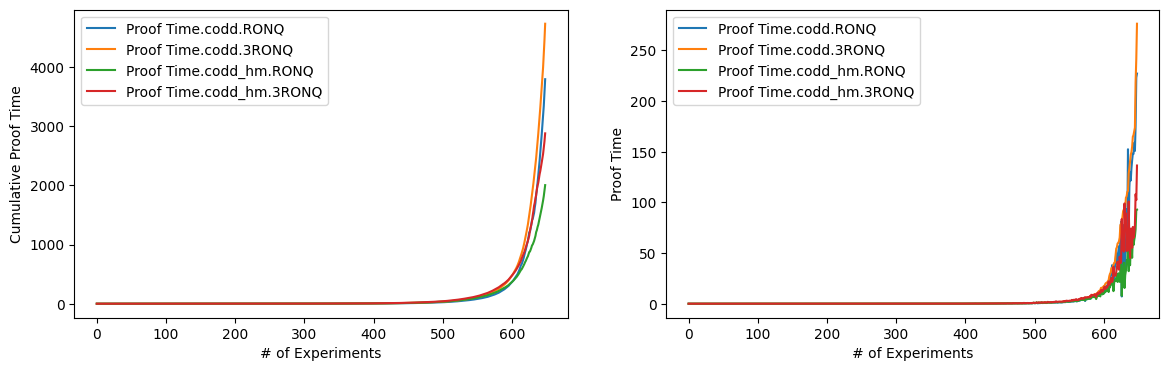

In [ ]:
cum_plot(final, 'Proof Time', sort_by=1, find_peaks=None, peak_time=1, suffixes_to_use=[0,1,2,3])

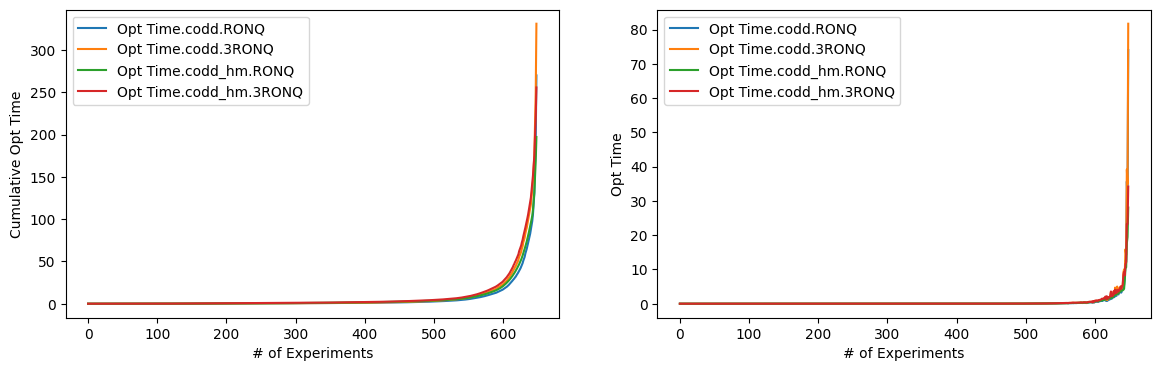

In [204]:
cum_plot(final, 'Opt Time', sort_by=2, find_peaks=None, peak_time=1, suffixes_to_use=[0,1,2,3])

# proof time vs # of expiriemnts, for every width (log scale)
plots on the left are cumulative, plots on the right are not

x's mark instances that take longer than a second and are local maxima. These instances are also printed

In [214]:
old_final = final.copy()
final = final[(final['Proof Time.codd.3RONQ'] > 0.1) & (final['Opt Time.codd_hm.3RONQ'] > 0.1)]

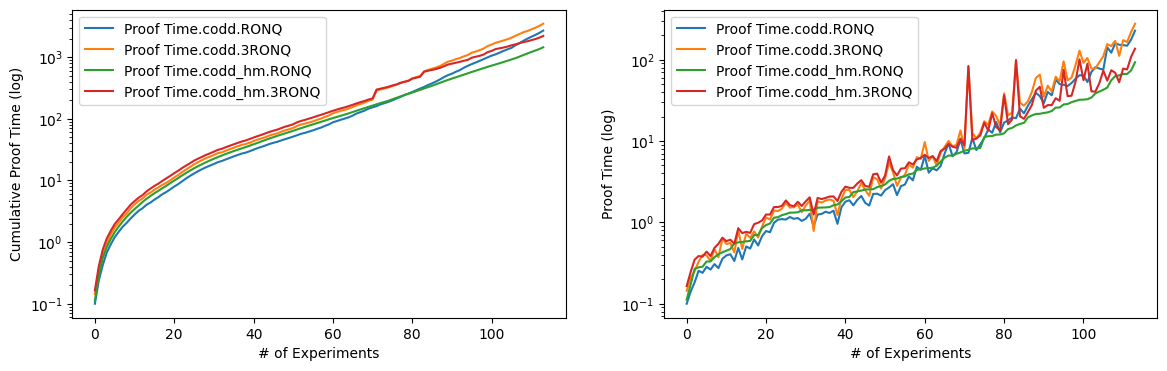

In [215]:
cum_plot(final, 'Proof Time', sort_by=2, find_peaks=None, peak_time=1, suffixes_to_use=[0,1,2,3], log=True)

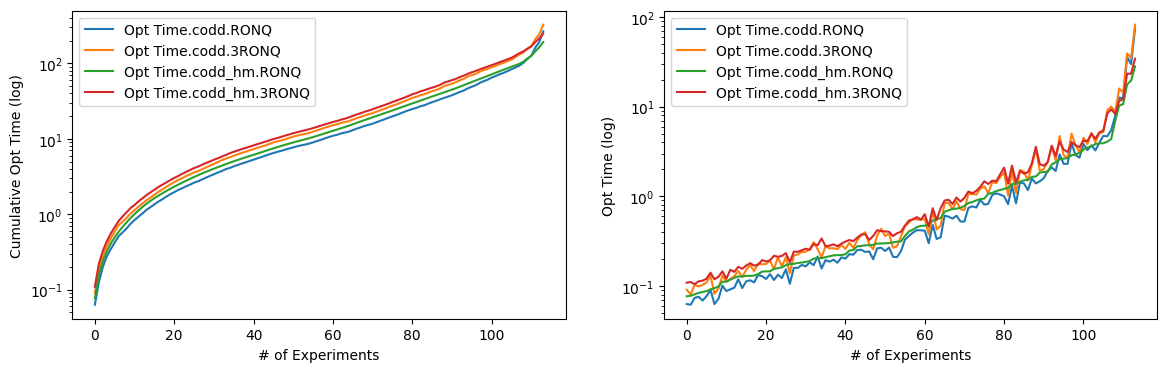

In [216]:
cum_plot(final, 'Opt Time', sort_by=2, find_peaks=None, peak_time=1, suffixes_to_use=[0,1,2,3], log=True)

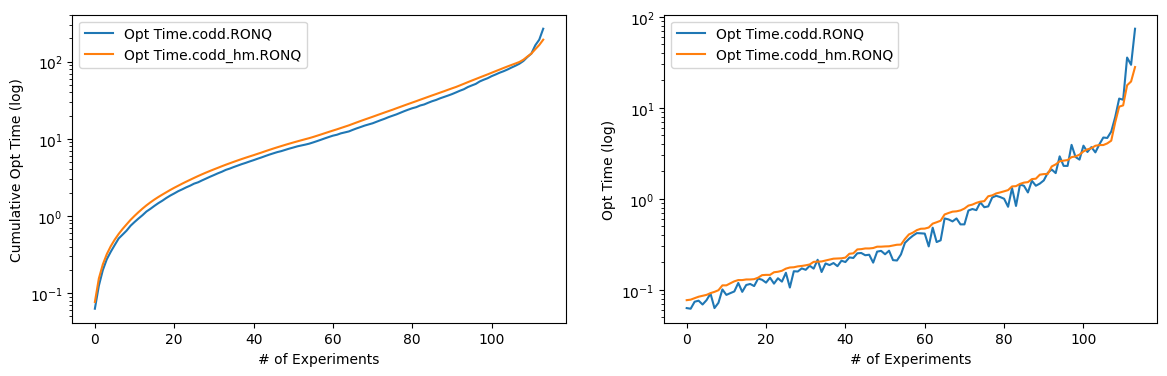

In [221]:
cum_plot(final, 'Opt Time', sort_by=2, find_peaks=None, peak_time=1, suffixes_to_use=[0,2], log=True)

# nodes vs # of expiriemnts, for every width
plots on the left are cumulative, plots on the right are not

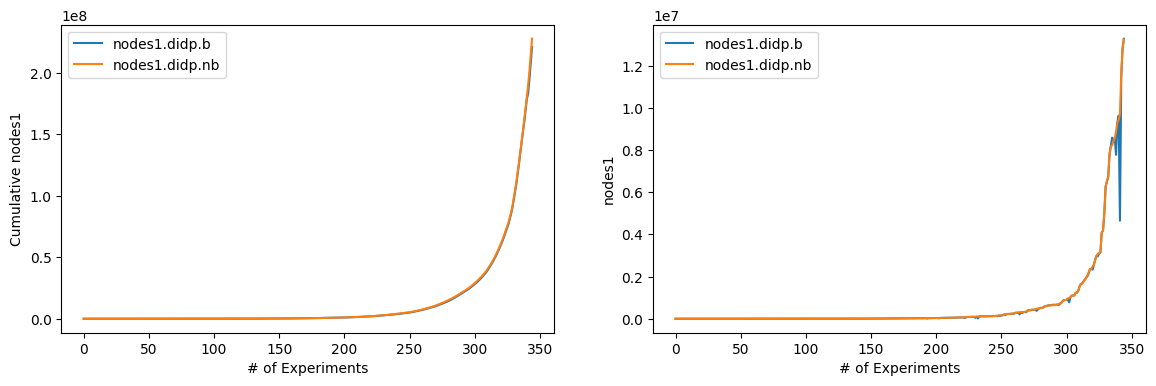

In [ ]:
cum_plot(final, 'nodes1', sort_by=1)

# nodes vs # of expiriemnts, for every width (log scale)
plots on the left are cumulative, plots on the right are not

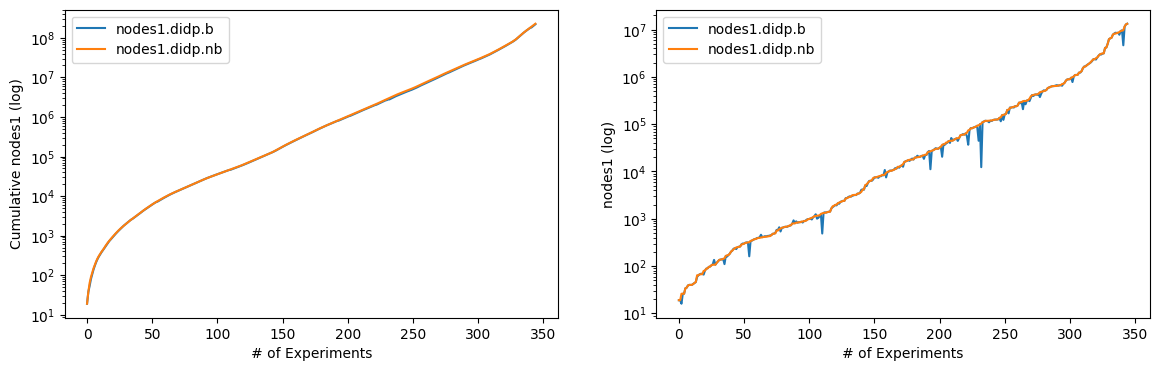

In [ ]:
cum_plot(final, 'nodes1', sort_by=1, log=True)

# log-log ECDF plots

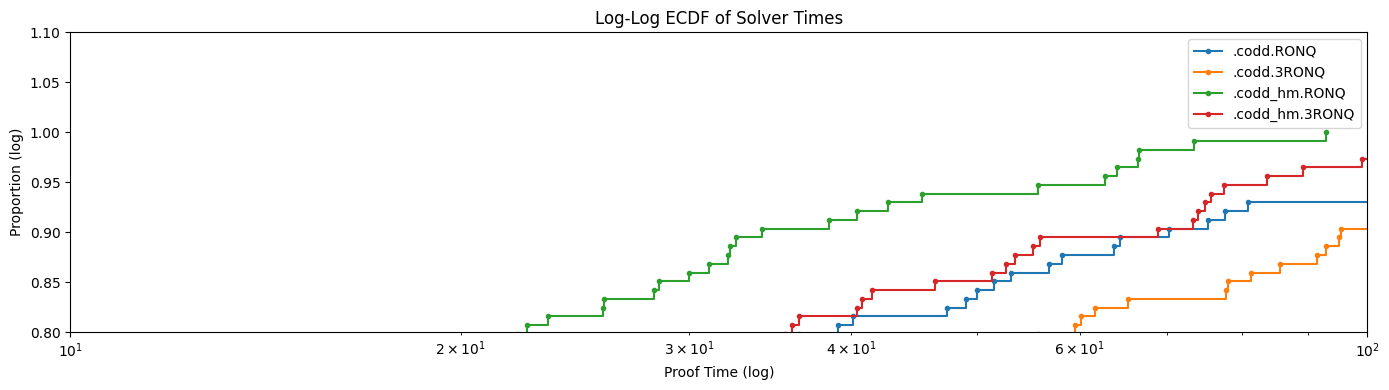

In [222]:
for solver in suffixes:
    times = final[f'Proof Time{solver}'].dropna().astype(np.float64)
    times = times[times > 0]
    plt.ecdf(times, label=solver, linestyle='-', marker='.')

plt.xscale('log')
#plt.yscale('log')
plt.xlim([10, 100])
plt.ylim([.8,1.1])
plt.xlabel('Proof Time (log)')
plt.ylabel('Proportion (log)')
plt.title('Log-Log ECDF of Solver Times')
plt.legend()
plt.tight_layout()
plt.show()

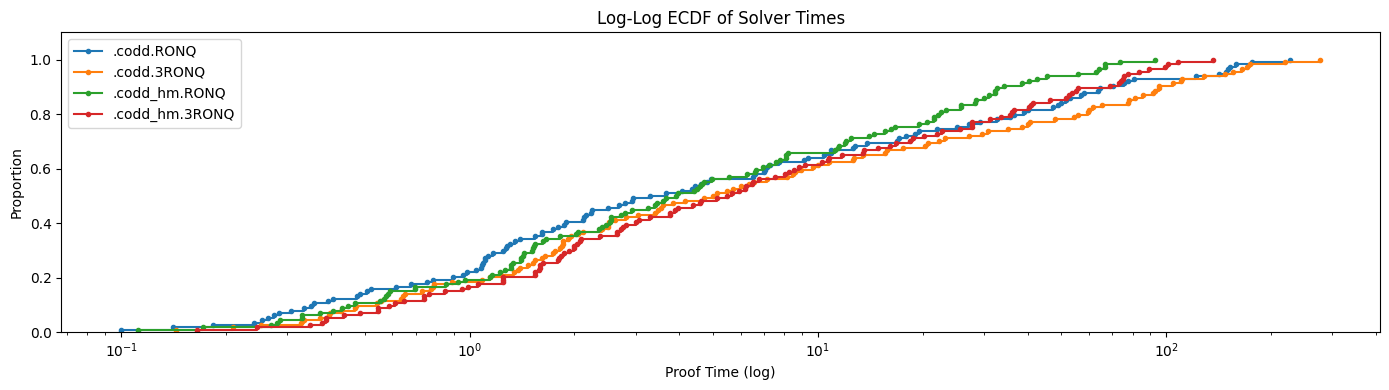

In [225]:
for solver in suffixes:
    times = final[f'Proof Time{solver}'].dropna().astype(np.float64)
    times = times[times > 0]
    plt.ecdf(times, label=solver, linestyle='-', marker='.')

plt.xscale('log')
#plt.yscale('log')
plt.ylim([0,1.1])
plt.xlabel('Proof Time (log)')
plt.ylabel('Proportion')
plt.title('Log-Log ECDF of Solver Times')
plt.legend()
plt.tight_layout()
plt.show()